In [1]:
# ============================================================
# Bachelor Thesis — ML Pipeline
# Prediction of Injury Risks in Professional Football
# Jerrin Jose | Westfälische Hochschule Gelsenkirchen
# Supervisor: Prof. Sebastian Büttner
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Libraries loaded successfully
Pandas version: 3.0.3
NumPy version: 2.4.6


In [2]:
# ============================================================
# STEP 2 — LOAD DATA
# ============================================================

# Source 1: Kaggle injury dataset (kolambekalpesh)
# Source 2: Transfermarkt appearances (dcaribou, CC0)
# Merged on: player name + season identifier

df = pd.read_csv('dataset.csv')

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape:          {df.shape}")
print(f"Rows:           {len(df)}")
print(f"Columns:        {len(df.columns)}")
print(f"Unique players: {df['p_id2'].nunique()}")
print(f"Seasons:        {sorted(df['start_year'].unique())}")

df.head()

DATASET OVERVIEW
Shape:          (1301, 40)
Rows:           1301
Columns:        40
Unique players: 604
Seasons:        [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


,p_id2,start_year,season_days_injured,total_days_injured,season_minutes_played,season_games_played,season_matches_in_squad,total_minutes_played,total_games_played,dob,...,name_key,player_id,season_x,tm_appearances,tm_minutes_total,tm_avg_minutes,season_y,max_matches_14d,target_injury,target_reinjury
0,aaronconnolly,2019,13,161,1312.0,24,28,2148.0,41,2000-01-28,...,aaronconnolly,434207.0,2019.0,25.0,1306.0,52.240000,2019.0,3.0,0,0
1,aaronconnolly,2020,71,161,836.0,17,28,2148.0,41,2000-01-28,...,aaronconnolly,434207.0,2020.0,17.0,791.0,46.529412,2020.0,2.0,1,0
2,aaroncresswell,2016,95,226,2247.0,26,27,13368.0,149,1989-12-15,...,aaroncresswell,92571.0,2016.0,27.0,2210.0,81.851852,2016.0,3.0,1,0
3,aaroncresswell,2018,87,226,1680.0,20,27,13368.0,149,1989-12-15,...,aaroncresswell,92571.0,2018.0,20.0,1590.0,79.500000,2018.0,2.0,1,0
4,aaroncresswell,2019,35,226,2870.0,31,31,13368.0,149,1989-12-15,...,aaroncresswell,92571.0,2019.0,32.0,2820.0,88.125000,2019.0,4.0,1,0


In [3]:
# ============================================================
# STEP 2b — EXPLORE COLUMNS
# ============================================================

# What columns do we have?
# Understanding each column before feature selection

print("All 40 columns in the dataset:")
print("=" * 50)
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")

All 40 columns in the dataset:
   1. p_id2
   2. start_year
   3. season_days_injured
   4. total_days_injured
   5. season_minutes_played
   6. season_games_played
   7. season_matches_in_squad
   8. total_minutes_played
   9. total_games_played
  10. dob
  11. height_cm
  12. weight_kg
  13. nationality
  14. work_rate
  15. pace
  16. physic
  17. fifa_rating
  18. position
  19. age
  20. cumulative_minutes_played
  21. cumulative_games_played
  22. minutes_per_game_prev_seasons
  23. avg_days_injured_prev_seasons
  24. avg_games_per_season_prev_seasons
  25. bmi
  26. work_rate_numeric
  27. position_numeric
  28. significant_injury_prev_season
  29. cumulative_days_injured
  30. season_days_injured_prev_season
  31. name_key
  32. player_id
  33. season_x
  34. tm_appearances
  35. tm_minutes_total
  36. tm_avg_minutes
  37. season_y
  38. max_matches_14d
  39. target_injury
  40. target_reinjury


In [4]:
# ============================================================
# STEP 2c — MISSING VALUES ANALYSIS
# ============================================================

# Before any processing — understand what data is missing
# and why

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

# Show only columns with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]
print("Columns with missing values:")
print("=" * 40)
print(missing_df.to_string())
print(f"\nTotal columns with missing values: {len(missing_df)}")

Columns with missing values:
                                   Missing Count  Missing %
pace                                          95        7.3
physic                                        95        7.3
position                                       2        0.2
cumulative_minutes_played                    604       46.4
cumulative_games_played                      604       46.4
minutes_per_game_prev_seasons                616       47.3
avg_days_injured_prev_seasons                604       46.4
avg_games_per_season_prev_seasons            604       46.4
position_numeric                               2        0.2
significant_injury_prev_season               604       46.4
cumulative_days_injured                      604       46.4
season_days_injured_prev_season              604       46.4
player_id                                     16        1.2
season_x                                      61        4.7
tm_appearances                                61        4.7
tm_minutes_

## Observation — Missing Values

Three groups of missing values identified:

**Group 1 — Large (46-47% missing):**
- significant_injury_prev_season, avg_days_injured_prev_seasons, cumulative_days_injured
- **Cause:** First-season appearances and player transfers — no prior season data available
- **Impact:** These are theoretically the strongest injury predictors (Hägglund et al., 2006)

**Group 2 — Small (4-7% missing):**
- pace, physic, max_matches_14d, tm_appearances
- **Cause:** Missing FIFA ratings and Transfermarkt data for some players
- **Impact:** Minor — median imputation sufficient

**Group 3 — Negligible (<2% missing):**
- position, position_numeric, player_id
- **Impact:** No significant effect

**Decision:** Apply median imputation — fitted on training data only to prevent data leakage.

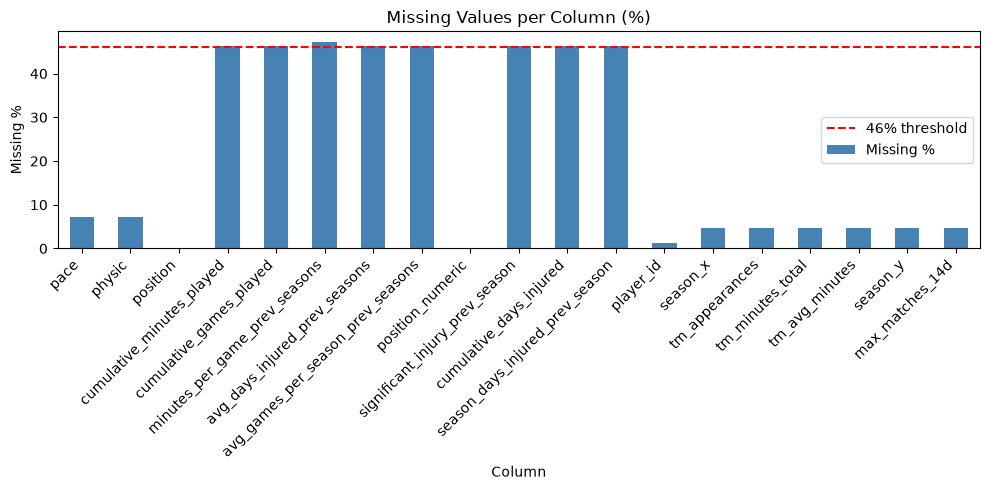

✅ Saved: results/missing_values.png


In [5]:

plt.figure(figsize=(10, 5))
missing_df['Missing %'].plot(
    kind='bar',
    color='steelblue'
)
plt.title('Missing Values per Column (%)')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=46, color='red', linestyle='--', label='46% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('results/missing_values.png', dpi=150)
plt.show()
print("✅ Saved: results/missing_values.png")